In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import random
from tqdm import tqdm
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt



In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

# BUGFIX: remove incompatible internal TF import that triggers protobuf error in TF 2.18
from tensorflow.keras.utils import to_categorical



2026-01-19 22:33:21.078436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768862001.092528      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768862001.096892      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-19 22:33:21.115923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
# BUGFIX: use the actual Kaggle filesystem paths provided in this environment.
DATA_DIR = "/kaggle/data/petfinder-pawpularity-score"
train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

assert os.path.isdir(train_dir), f"train_dir not found: {train_dir}"
assert os.path.isdir(test_dir), f"test_dir not found: {test_dir}"



(720, 405, 3)


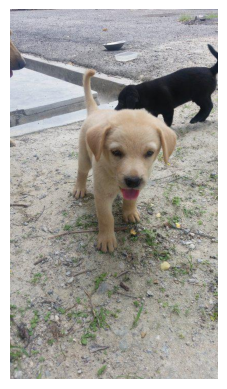

In [4]:
path0 = os.path.join(train_dir, "0007de18844b0dbbb5e1f607da0606e0.jpg")
image = cv2.imread(path0)
if image is None:
    raise FileNotFoundError(f"cv2.imread failed for: {path0}")
print(image.shape)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()



(60, 60, 3)


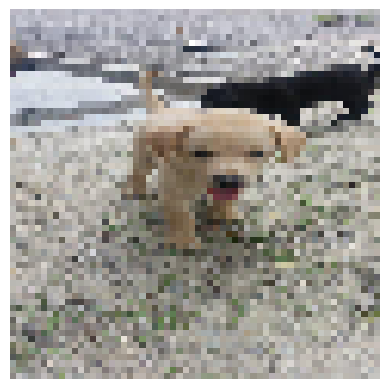

In [5]:
image2 = cv2.resize(image, dsize=(60, 60), interpolation=cv2.INTER_CUBIC)
print(image2.shape)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()



In [6]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
train



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


In [7]:
train["Pawpularity"].unique()



array([ 55, 100,  27,  51,  48,  32,  25,  36,  34,  60,  10,  26,  14,
         3,  31,  21,  39,  22,  30,  38,  29,  90,  37,  40,  28,  20,
        42,   7,  15,  24,  79,  59,  12,  41,  85,  65,  43,  16,  35,
        52,  62,  80,  53,  75,  66,  23,  47,  13,   5,  19,  64,  45,
        49,  33,  18,  71,  50,  11,  91,  57,  76,  63,  17,  98,  61,
        67,   8,  46,   2,  54,  68,  89,  58,  73,  44,   4,  56,  88,
        72,  83,  95,  92,  77,  78,   9,  96,  70,  69,   6,  86,  81,
        87,  82,  97,   1,  84,  94,  74,  93,  99])

In [8]:
N0 = list(range(100))
N1 = list(range(1, 101))
normal_mapping = dict(zip(N1, N0))
reverse_mapping = dict(zip(N0, N1))



In [9]:
train[train["Id"] == "0007de18844b0dbbb5e1f607da0606e0"]["Pawpularity"].tolist()[0]



63

In [10]:
# BUGFIX: guard against non-image files and failed reads (cv2.imread returns None).
trainimg0 = []
trainlabel0 = []

# Small speed/robustness: build Id->Pawpularity dict once (same semantics).
id_to_paw = dict(zip(train["Id"].values, train["Pawpularity"].values))

for im in tqdm(os.listdir(train_dir)):
    if not im.lower().endswith(".jpg"):
        continue
    img_path = os.path.join(train_dir, im)
    image = cv2.imread(img_path)
    if image is None:
        continue
    image2 = cv2.resize(image, dsize=(60, 60), interpolation=cv2.INTER_CUBIC)
    trainimg0.append(image2)

    img_id = im[:-4]
    # Keep original behavior (would have errored if missing); here we skip if unexpected.
    if img_id not in id_to_paw:
        trainimg0.pop()
        continue
    trainlabel0.append(id_to_paw[img_id])

print(f"Loaded {len(trainimg0)} train images, {len(trainlabel0)} labels")



100%|██████████| 8921/8921 [00:25<00:00, 348.38it/s]

Loaded 8920 train images, 8920 labels


In [11]:
trainlabel1 = pd.Series(trainlabel0).map(normal_mapping)



In [12]:
trainimg = np.array(trainimg0)
trainlabel = np.array(trainlabel1)
print(trainimg.shape, trainlabel.shape)



(8920, 60, 60, 3) (8920,)


In [13]:
m = len(trainimg)
M = list(range(m))
random.seed(2021)
random.shuffle(M)



In [14]:
trainX = trainimg[M[0 : (m // 4) * 3]]
trainY0 = trainlabel[M[0 : (m // 4) * 3]]

testX = trainimg[M[(m // 4) * 3 :]]
testY0 = trainlabel[M[(m // 4) * 3 :]]



In [15]:
labels1 = to_categorical(trainY0)
trainY = np.array(labels1)



In [16]:
trainx, testx, trainy, testy = train_test_split(
    trainX, trainY, test_size=0.2, random_state=44
)



In [17]:
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)



(5352, 60, 60, 3)
(1338, 60, 60, 3)
(5352, 100)
(1338, 100)


In [18]:
model = Sequential()
model.add(Conv2D(32, (4, 4), input_shape=(60, 60, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(400, activation="relu"))
model.add(Dense(100, activation="softmax"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-19 22:33:53.751617: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768862033.752107      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


In [19]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])



In [20]:
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 57, 57, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 400)            │     4,326,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        40,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,964 (16.73 MB)

 Trainable params: 4,386,964 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
his = model.fit(
    trainx, trainy, validation_split=0.2, epochs=30, batch_size=92, verbose=2
)



Epoch 1/30


I0000 00:00:1768862035.154639      69 service.cc:148] XLA service 0x7f078c00a4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768862035.154672      69 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-19 22:33:55.174578: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768862035.268912      69 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-01-19 22:33:55.953059: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_640_0', 1044 bytes spill stores, 732 bytes spill loads

2026-01-19 22:33:56.570983: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_640', 28 bytes spi

47/47 - 14s - 307ms/step - accuracy: 0.0243 - loss: 29.5789 - val_accuracy: 0.0271 - val_loss: 4.3658
Epoch 2/30
47/47 - 0s - 4ms/step - accuracy: 0.0769 - loss: 4.1332 - val_accuracy: 0.0215 - val_loss: 4.3906
Epoch 3/30
47/47 - 0s - 4ms/step - accuracy: 0.1640 - loss: 3.5993 - val_accuracy: 0.0215 - val_loss: 4.6933
Epoch 4/30
47/47 - 0s - 4ms/step - accuracy: 0.3242 - loss: 2.8372 - val_accuracy: 0.0299 - val_loss: 4.9710
Epoch 5/30
47/47 - 0s - 4ms/step - accuracy: 0.4887 - loss: 2.0822 - val_accuracy: 0.0299 - val_loss: 5.8030
Epoch 6/30
47/47 - 0s - 4ms/step - accuracy: 0.6333 - loss: 1.4819 - val_accuracy: 0.0243 - val_loss: 6.7857
Epoch 7/30
47/47 - 0s - 4ms/step - accuracy: 0.7125 - loss: 1.1516 - val_accuracy: 0.0271 - val_loss: 7.2303
Epoch 8/30
47/47 - 0s - 4ms/step - accuracy: 0.7912 - loss: 0.8965 - val_accuracy: 0.0233 - val_loss: 8.3941
Epoch 9/30
47/47 - 0s - 4ms/step - accuracy: 0.8374 - loss: 0.6979 - val_accuracy: 0.0299 - val_loss: 8.2489
Epoch 10/30
47/47 - 0s - 4

In [22]:
y_pred = model.predict(testx, verbose=0)
pred = np.argmax(y_pred, axis=1)
ground = np.argmax(testy, axis=1)
print(classification_report(ground, pred, zero_division=0))



2026-01-19 22:34:15.856316: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 508 bytes spill stores, 544 bytes spill loads

2026-01-19 22:34:16.963771: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 536 bytes spill stores, 600 bytes spill loads



              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         9
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         6
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         8
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.00         9
          14       0.00      0.00      0.00        11
          15       0.00      0.00      0.00        11
          16       0.06      0.05      0.05        21
          17       0.00      0.00      0.00        20
          18       0.00    

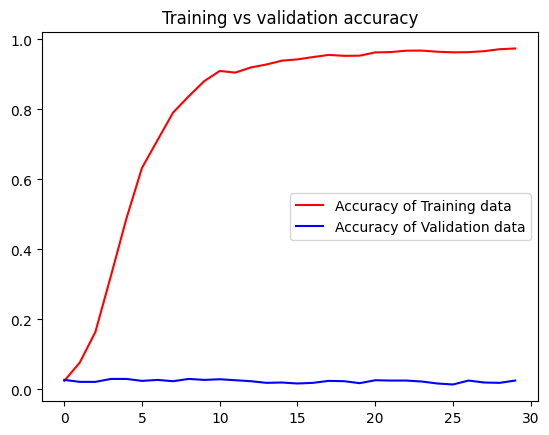

<Figure size 640x480 with 0 Axes>

In [23]:
get_acc = his.history["accuracy"]
value_acc = his.history["val_accuracy"]
get_loss = his.history["loss"]
validation_loss = his.history["val_loss"]

epochs = range(len(get_acc))
plt.plot(epochs, get_acc, "r", label="Accuracy of Training data")
plt.plot(epochs, value_acc, "b", label="Accuracy of Validation data")
plt.title("Training vs validation accuracy")
plt.legend(loc=0)
plt.figure()
plt.show()



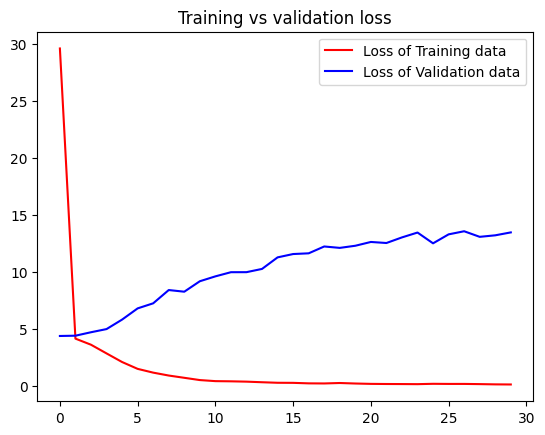

<Figure size 640x480 with 0 Axes>

In [24]:
epochs = range(len(get_loss))
plt.plot(epochs, get_loss, "r", label="Loss of Training data")
plt.plot(epochs, validation_loss, "b", label="Loss of Validation data")
plt.title("Training vs validation loss")
plt.legend(loc=0)
plt.figure()
plt.show()



In [25]:
pred2 = model.predict(testX, verbose=0)
print(pred2.shape)

PRED = []
for item in pred2:
    value2 = np.argmax(item)
    PRED.append(value2)
print(pd.Series(PRED).value_counts().head())



2026-01-19 22:34:18.529262: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 536 bytes spill stores, 600 bytes spill loads



(2230, 100)
99    149
30    108
25    106
22     94
35     93
Name: count, dtype: int64


In [26]:
ANS = testY0
print(pd.Series(ANS).value_counts().head())
accuracy = accuracy_score(ANS, PRED)
print(accuracy)



25    86
27    80
28    80
99    69
31    69
Name: count, dtype: int64
0.02197309417040359


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


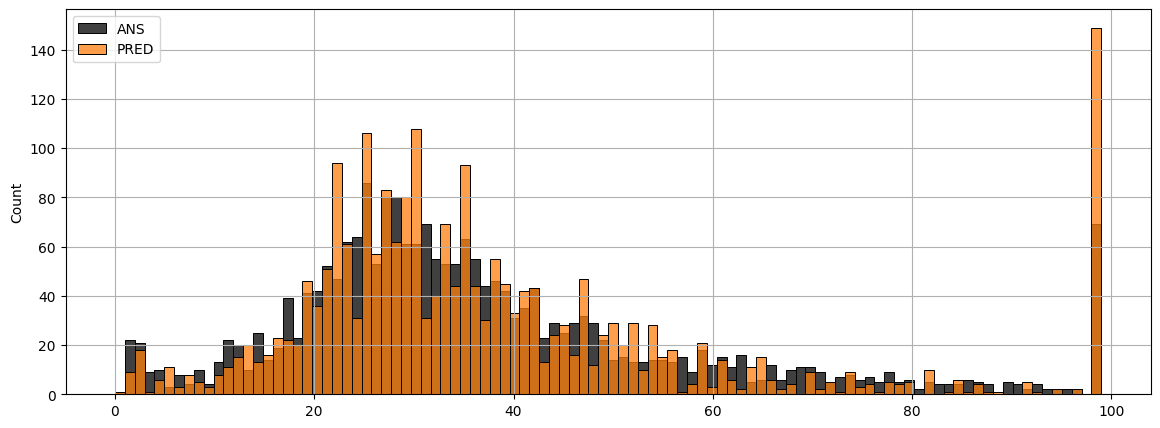

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(ANS, label="ANS", ax=ax, color="black", bins=100)
sns.histplot(PRED, label="PRED", ax=ax, color="C1", bins=100)
ax.legend()
ax.grid()
plt.show()



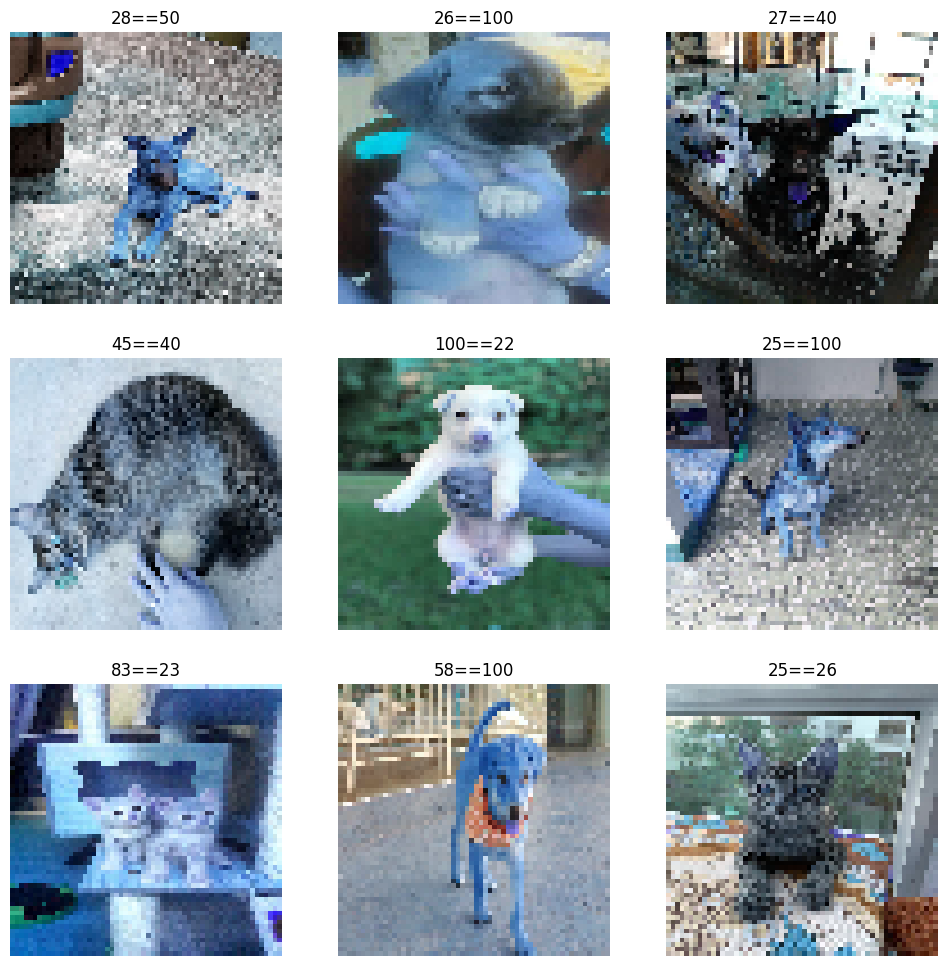

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(9):
    r = i // 3
    c = i % 3
    img1 = testX[i]
    axs[r][c].axis("off")
    actual = reverse_mapping[int(testY0[i])]
    predict = reverse_mapping[int(PRED[i])]
    axs[r][c].set_title(str(actual) + "==" + str(predict))
    axs[r][c].imshow(img1)
plt.show()



In [29]:
# BUGFIX: guard against failed reads; also keep deterministic order aligned to sample submission later.
TESTX = []
testim = []

for im in tqdm(os.listdir(test_dir)):
    if not im.lower().endswith(".jpg"):
        continue
    img_path = os.path.join(test_dir, im)
    image = cv2.imread(img_path)
    if image is None:
        continue
    image2 = cv2.resize(image, dsize=(60, 60), interpolation=cv2.INTER_CUBIC)
    TESTX.append(image2)
    testim.append(im[:-4])

TESTX = np.array(TESTX)
print(TESTX.shape, len(testim))



100%|██████████| 993/993 [00:02<00:00, 404.29it/s]

(992, 60, 60, 3) 992


In [30]:
test_pred2 = model.predict(TESTX, verbose=0)

TESTPRED = []
for item in test_pred2:
    value = np.argmax(item)
    value2 = reverse_mapping[int(value)]
    TESTPRED.append(float(value2))
print(pd.Series(TESTPRED).value_counts().head())



36.0     53
100.0    48
26.0     46
31.0     42
30.0     40
Name: count, dtype: int64


In [31]:
sample = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
sample.head()



,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,64.06
1,caddfb3f8bff9c4b95dbe022018eea21,27.71
2,582eeabd4a448a53ebb79995888a4b0b,5.06
3,afc1ad7f0c5eea880759d09e77f7deee,2.64
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,81.51


In [32]:
# BUGFIX: ensure predictions align to the sample submission Id order (do NOT sort arbitrarily).
pred_df = pd.DataFrame({"Id": testim, "Pawpularity": TESTPRED})
sub = sample[["Id"]].merge(pred_df, on="Id", how="left")

# If any images were skipped unexpectedly, fill with a safe default (mean prediction) to keep submission valid.
if sub["Pawpularity"].isna().any():
    sub["Pawpularity"] = sub["Pawpularity"].fillna(float(np.mean(TESTPRED)))

sub



,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,36.0
1,caddfb3f8bff9c4b95dbe022018eea21,5.0
2,582eeabd4a448a53ebb79995888a4b0b,60.0
3,afc1ad7f0c5eea880759d09e77f7deee,29.0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,100.0
...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,26.0
988,8064261ce5f7197fdc849641b3192eef,52.0
989,a5ff4923e393fa08e67da31c7eb4edd5,31.0
990,fa6a53f962225c17b22392748f91f9ac,57.0


In [33]:
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", sub.shape)
print(sub.head())

Wrote submission.csv with shape: (992, 2)
                                 Id  Pawpularity
0  ee51b99832f1ba868f646df93d2b6b81         36.0
1  caddfb3f8bff9c4b95dbe022018eea21          5.0
2  582eeabd4a448a53ebb79995888a4b0b         60.0
3  afc1ad7f0c5eea880759d09e77f7deee         29.0
4  d5bdf3446e86ce4ec67ce7a00f1cccc2        100.0
